In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv(
    "cleaned_vgsales.csv",
    dtype={
        "Rank": np.int16,
        "Year": np.int16,
        "NA_Sales": np.float32,
        "EU_Sales": np.float32,
        "JP_Sales":	np.float32,
        "Other_Sales": np.float32,
        "Global_Sales": np.float32,
    },
    index_col=0,
)
df.drop(columns=['is_global_ok'], inplace=True)
df

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
Rank,,,,,,,,,,
1,Wii Sports,Wii,2006,Sports,Nintendo,41.490002,29.02,3.77,8.46,82.739998
2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.080000,3.58,6.81,0.77,40.240002
3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.850000,12.88,3.79,3.31,35.830002
4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.750000,11.01,3.28,2.96,33.000000
5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.270000,8.89,10.22,1.00,31.379999
...,...,...,...,...,...,...,...,...,...,...
16596,Woody Woodpecker in Crazy Castle 5,GBA,2002,Platform,Kemco,0.010000,0.00,0.00,0.00,0.010000
16597,Men in Black II: Alien Escape,GC,2003,Shooter,Infogrames,0.010000,0.00,0.00,0.00,0.010000
16598,SCORE International Baja 1000: The Official Game,PS2,2008,Racing,Activision,0.000000,0.00,0.00,0.00,0.000000


In [15]:
df.rename(columns={"Publisher": "Company"}, inplace=True)
df.head()

,Name,Platform,Year,Genre,Company,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
Rank,,,,,,,,,,
1,Wii Sports,Wii,2006,Sports,Nintendo,41.490002,29.02,3.77,8.46,82.739998
2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.080000,3.58,6.81,0.77,40.240002
3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.850000,12.88,3.79,3.31,35.830002
4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.750000,11.01,3.28,2.96,33.000000
5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.270000,8.89,10.22,1.00,31.379999


In [16]:
best_5_compny_sales = df.groupby("Company")["Global_Sales"].sum().sort_values(ascending=False).nlargest(5)
pd.DataFrame(best_5_compny_sales)

,Global_Sales
Company,
Nintendo,1786.359985
Electronic Arts,1110.150024
Activision,727.109985
Sony Computer Entertainment,607.489990
Ubisoft,474.510010


<Axes: title={'center': 'Top 5 Companies by Global Sales'}, xlabel='Company', ylabel='Global Sales'>

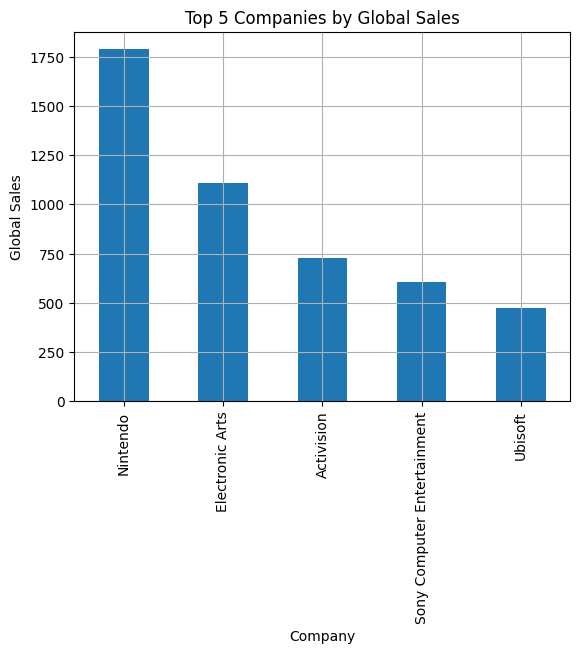

In [17]:
best_5_compny_sales.plot(kind="bar",grid=True, title="Top 5 Companies by Global Sales", ylabel="Global Sales", xlabel="Company")

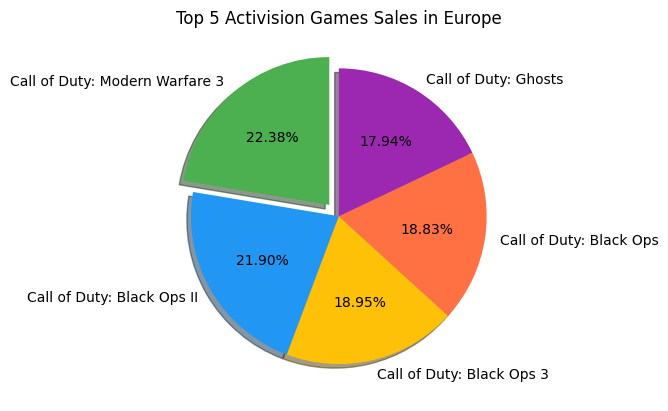

In [ ]:
activision_games = df[df["Company"] == "Activision"]
EU_Sales_top_5_games_by_activision = activision_games.groupby("Name")["EU_Sales"].sum().sort_values(ascending=False).nlargest(5)
games = EU_Sales_top_5_games_by_activision.index
sales = EU_Sales_top_5_games_by_activision 
colors = ["#4CAF50","#2196F3","#FFC107","#FF7043","#9C27B0"]
plt.pie(
    sales,
    labels=games,
    explode=[0.1, 0, 0, 0, 0],
    autopct='%1.2f%%',
    colors=colors,
    startangle=90,
    shadow=True
)
plt.title("Top 5 Activision Games Sales in Europe")
plt.show()